# Real-Time Speech Emotion Recognition for Context-Aware LLMs

**End-to-end research implementation:** RAVDESS + CREMA-D → Feature Extraction → CNN/CNN+LSTM/HuBERT → Real-Time Pipeline → LLM Integration

---
## Dataset Download Instructions

Run the shell commands in Cell 1 below, OR download manually:

| Dataset | URL | Size | License |
|---------|-----|------|---------|
| **RAVDESS** | https://zenodo.org/record/1188976 → `Audio_Speech_Actors_01-24.zip` | ~215 MB | CC BY-NC-SA 4.0 |
| **CREMA-D** | `git clone https://github.com/CheyneyComputerScience/CREMA-D` → use `AudioWAV/` folder | ~4 GB | Open |
| **IEMOCAP** | https://sail.usc.edu/iemocap/ (free academic request, 24-48h) | ~11 GB | Academic |

**Expected folder layout after download:**
```
data/
  ravdess/
    Actor_01/03-01-01-01-01-01-01.wav
    Actor_02/...
  crema-d/
    AudioWAV/1001_DFA_ANG_XX.wav
    VideoDemographics.csv
```

In [1]:
# ============================================================
# CELL 2 — Imports & global config
# ============================================================
import os, re, random, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- Global config ----

CFG = {
    'seed'        : 42,
    'sr'          : 16_000,
    'clip_sec'    : 2.0,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'n_fft'       : 512,
    'hop_length'  : 160,
    'win_length'  : 400,
    'f_min'       : 80,
    'f_max'       : 7600,
    'batch_size'  : 8,
    'epochs'      : 30,
    'lr'          : 1e-4,
    'dropout'     : 0.3,
    'num_workers' : 0,
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_classes' : 6,   # 6-class intersection of RAVDESS+CREMA-D
}

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if CFG['device'] == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print(f"Device: {CFG['device']}")
print(f"PyTorch: {torch.__version__} | torchaudio: {torchaudio.__version__}")

Device: cuda
PyTorch: 2.5.1+cu121 | torchaudio: 2.5.1+cu121


c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples: 8690
label
happy      1463
sad        1463
angry      1463
fearful    1463
disgust    1463
neutral    1375
Name: count, dtype: int64


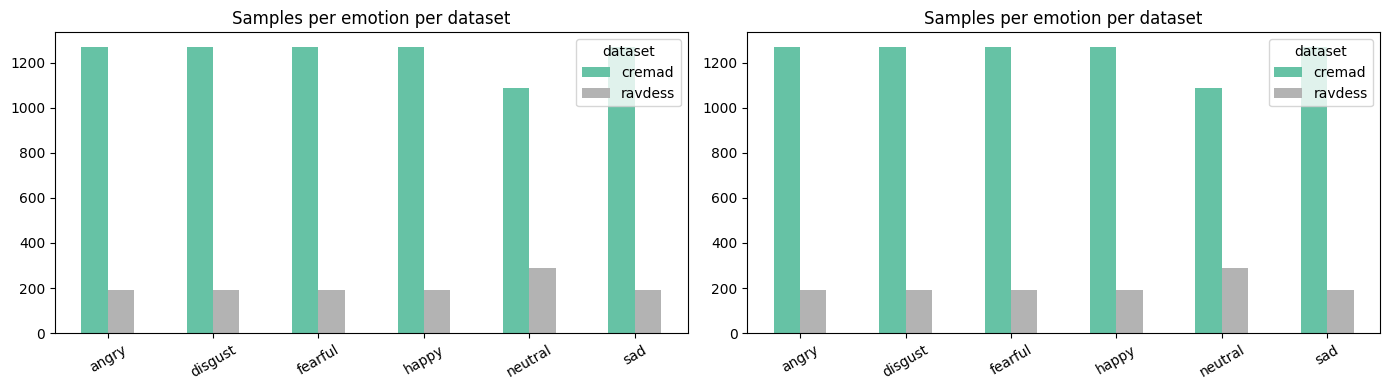

In [2]:
# ============================================================
# CELL 3 — Dataset Metadata Parsing
# ============================================================

# ---------- RAVDESS emotion map ----------
# Filename: 03-01-EM-IN-ST-RP-AC.wav  (EM = emotion code)
# We unify RAVDESS 8-class → 6-class to match CREMA-D
RAVDESS_MAP = {
    '01': 'neutral',
    '02': 'calm',     # will be merged into 'neutral'
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised', # dropped from combined set
}

# CREMA-D emotion map
CREMAD_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fearful',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad',
}

# Unified 6 classes (drop calm/surprised from RAVDESS)
UNIFIED_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']


def parse_ravdess(root='data/ravdess'):
    records = []
    for wav in Path(root).rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) != 7:
            continue
        em_code  = parts[2]
        actor_id = int(parts[6])
        label    = RAVDESS_MAP.get(em_code)
        if label in UNIFIED_EMOTIONS:
            records.append({'path': str(wav), 'label': label,
                             'speaker_id': f'R{actor_id:03d}', 'dataset': 'ravdess'})
        elif label == 'calm':   # merge calm → neutral
            records.append({'path': str(wav), 'label': 'neutral',
                             'speaker_id': f'R{actor_id:03d}', 'dataset': 'ravdess'})
    return pd.DataFrame(records)


def parse_cremad(audio_dir='data/crema-d/AudioWAV',
                 demo_csv='data/crema-d/VideoDemographics.csv'):
    records = []
    for wav in Path(audio_dir).glob('*.wav'):
        parts = wav.stem.split('_')
        if len(parts) < 3:
            continue
        actor_id = parts[0]
        em_code  = parts[2]
        label    = CREMAD_MAP.get(em_code)
        if label:
            records.append({'path': str(wav), 'label': label,
                             'speaker_id': f'C{actor_id}', 'dataset': 'cremad'})
    return pd.DataFrame(records)


df_rav  = parse_ravdess()
df_cre  = parse_cremad()
df_all  = pd.concat([df_rav, df_cre], ignore_index=True)

le = LabelEncoder().fit(UNIFIED_EMOTIONS)
df_all['label_id'] = le.transform(df_all['label'])

print(f"Total samples: {len(df_all)}")
print(df_all['label'].value_counts())

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, df) in zip(axes, [('Combined', df_all), ('Per dataset', df_all)]):
    df_all.groupby(['label', 'dataset']).size().unstack().plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title('Samples per emotion per dataset')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# CELL 4 — Speaker-Independent Train/Val/Test Split
# ============================================================

def speaker_independent_split(df, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Split by speaker, NOT by sample.
    Prevents the model from learning speaker identity instead of emotion.
    Without this, accuracy inflates by ~10-15% on seen speakers.
    """
    speakers = df['speaker_id'].unique().tolist()
    random.seed(seed)
    random.shuffle(speakers)
    n      = len(speakers)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)

    test_spk  = set(speakers[:n_test])
    val_spk   = set(speakers[n_test:n_test + n_val])
    train_spk = set(speakers[n_test + n_val:])

    df_train = df[df['speaker_id'].isin(train_spk)].reset_index(drop=True)
    df_val   = df[df['speaker_id'].isin(val_spk)].reset_index(drop=True)
    df_test  = df[df['speaker_id'].isin(test_spk)].reset_index(drop=True)
    return df_train, df_val, df_test


df_train, df_val, df_test = speaker_independent_split(df_all)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Train speakers: {df_train['speaker_id'].nunique()}")
print(f"Val speakers:   {df_val['speaker_id'].nunique()}")
print(f"Test speakers:  {df_test['speaker_id'].nunique()}")

# Verify no speaker leakage
assert len(set(df_train['speaker_id']) & set(df_test['speaker_id'])) == 0, 'Leakage!'
assert len(set(df_train['speaker_id']) & set(df_val['speaker_id']))  == 0, 'Leakage!'
print('No speaker leakage confirmed.')

Train: 6088 | Val: 1268 | Test: 1334
Train speakers: 81
Val speakers:   17
Test speakers:  17
No speaker leakage confirmed.


MFCC shape     : torch.Size([1, 120, 201])
Log-Mel shape  : torch.Size([1, 128, 201])
Waveform shape : torch.Size([1, 32000])


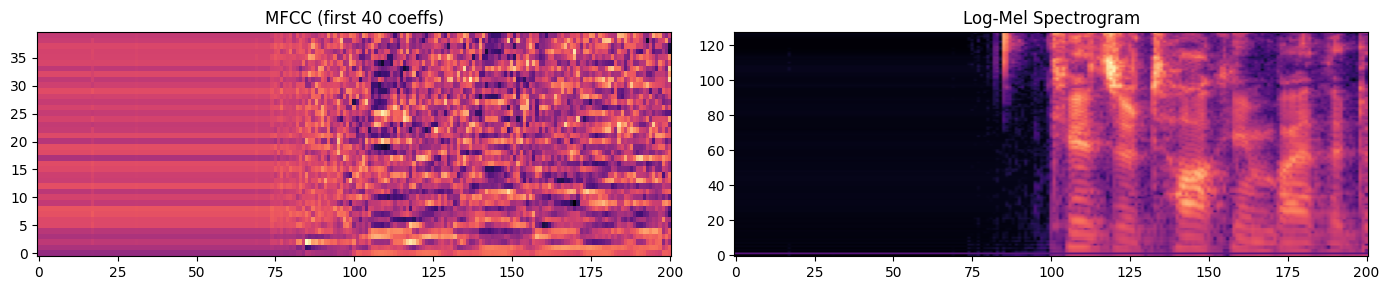

In [4]:
# ============================================================
# CELL 5 — Audio Preprocessor
# ============================================================

class AudioPreprocessor:
    """
    Loads, resamples, pads/trims, and extracts features from audio.

    Returns:
      mfcc_full : [1, 120, T_frames]  (MFCC + delta + delta-delta)
      log_mel   : [1, 128, T_frames]  (log mel spectrogram)
      wav       : [1, T_samples]      (raw waveform for HuBERT)
    """

    def __init__(self, cfg=CFG):
        self.sr        = cfg['sr']
        self.n_samples = int(cfg['sr'] * cfg['clip_sec'])

        self.mfcc_tfm = T.MFCC(
            sample_rate=cfg['sr'], n_mfcc=cfg['n_mfcc'],
            melkwargs={
                'n_fft'      : cfg['n_fft'],
                'hop_length' : cfg['hop_length'],
                'win_length' : cfg['win_length'],
                'n_mels'     : cfg['n_mels'],
                'f_min'      : cfg['f_min'],
                'f_max'      : cfg['f_max'],
            }
        )
        self.mel_tfm = T.MelSpectrogram(
            sample_rate=cfg['sr'], n_fft=cfg['n_fft'],
            hop_length=cfg['hop_length'], win_length=cfg['win_length'],
            n_mels=cfg['n_mels'], f_min=cfg['f_min'], f_max=cfg['f_max']
        )
        self.amp_to_db = T.AmplitudeToDB(top_db=80)
        self.delta     = T.ComputeDeltas()

    def load(self, path):
        wav, sr = torchaudio.load(path)
        if wav.shape[0] > 1:
            wav = wav.mean(0, keepdim=True)        # stereo → mono
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        return wav

    def pad_or_trim(self, wav):
        n = wav.shape[-1]
        if n >= self.n_samples:
            return wav[..., :self.n_samples]
        pad = self.n_samples - n
        return F.pad(wav, (pad // 2, pad - pad // 2))

    @staticmethod
    def normalize(t):
        mean = t.mean(dim=-1, keepdim=True)
        std  = t.std(dim=-1, keepdim=True).clamp(min=1e-6)
        return (t - mean) / std

    def __call__(self, path):
        wav  = self.load(path)
        wav  = self.pad_or_trim(wav)

        mfcc   = self.mfcc_tfm(wav)
        d1     = self.delta(mfcc)
        d2     = self.delta(d1)
        mfcc_f = torch.cat([mfcc, d1, d2], dim=1)     # [1, 120, T]

        mel  = self.mel_tfm(wav)
        lmel = self.amp_to_db(mel)                     # [1, 128, T]

        return (
            self.normalize(mfcc_f),
            self.normalize(lmel),
            wav / (wav.abs().max().clamp(min=1e-6))    # peak-normalized waveform
        )


preprocessor = AudioPreprocessor()

# Quick sanity check
sample_path = df_train['path'].iloc[0]
mfcc, lmel, wav = preprocessor(sample_path)
print(f'MFCC shape     : {mfcc.shape}')   # [1, 120, 300]
print(f'Log-Mel shape  : {lmel.shape}')   # [1, 128, 300]
print(f'Waveform shape : {wav.shape}')    # [1, 48000]

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3))
ax1.imshow(mfcc[0, :40].numpy(), aspect='auto', origin='lower', cmap='magma')
ax1.set_title('MFCC (first 40 coeffs)')
ax2.imshow(lmel[0].numpy(), aspect='auto', origin='lower', cmap='magma')
ax2.set_title('Log-Mel Spectrogram')
plt.tight_layout(); plt.show()

In [5]:
# ============================================================
# CELL 6 — Data Augmentation
# ============================================================

class SpeechAugment:
    """Augmentations on raw waveform [1, T] + spectrogram [C, F, T]."""

    def __init__(self, sr=16_000, p=0.2):
        self.sr = sr
        self.p  = p

    def add_gaussian_noise(self, wav, snr_db_range=(10, 30)):
        snr           = random.uniform(*snr_db_range)
        sig_pow       = wav.norm(p=2) ** 2 / wav.numel()
        noise_pow     = sig_pow / (10 ** (snr / 10))
        noise         = torch.randn_like(wav) * noise_pow.sqrt()
        return (wav + noise).clamp(-1.0, 1.0)

    def add_background_noise(self, wav, noise_level=(0.002, 0.015)):
        """Adds pink noise (1/f) to simulate room acoustics."""
        f     = torch.fft.rfftfreq(wav.shape[-1]).clamp(min=1e-6)
        pink  = (1.0 / f.sqrt()) * torch.randn(len(f), dtype=torch.complex64)
        noise = torch.fft.irfft(pink, n=wav.shape[-1]).unsqueeze(0)
        noise = noise / noise.abs().max().clamp(min=1e-6)
        alpha = random.uniform(*noise_level)
        return (wav + alpha * noise).clamp(-1.0, 1.0)

    def pitch_shift(self, wav, n_steps_range=(-3, 3)):
        n = random.randint(*n_steps_range)
        if n == 0:
            return wav
        return torchaudio.functional.pitch_shift(wav, self.sr, n)

    def time_stretch_spec(self, spec, rate_range=(0.8, 1.2)):
        """SpecAugment-compatible stretch applied on magnitude spectrum."""
        rate = random.uniform(*rate_range)
        T    = spec.shape[-1]
        new_T = int(T / rate)
        stretched = F.interpolate(
            spec.unsqueeze(0).float(), size=(spec.shape[-2], new_T),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        if new_T >= T:
            return stretched[..., :T]
        return F.pad(stretched, (0, T - new_T))

    def time_mask(self, spec, max_pct=0.20):
        T = spec.shape[-1]
        w = int(T * max_pct * random.random())
        s = random.randint(0, max(0, T - w - 1))
        spec = spec.clone()
        spec[..., s:s + w] = 0.0
        return spec

    def freq_mask(self, spec, max_pct=0.15):
        F_ = spec.shape[-2]
        w  = int(F_ * max_pct * random.random())
        s  = random.randint(0, max(0, F_ - w - 1))
        spec = spec.clone()
        spec[:, s:s + w, :] = 0.0
        return spec

    def volume_perturbation(self, wav, db_range=(-6, 6)):
        db = random.uniform(*db_range)
        return (wav * (10 ** (db / 20))).clamp(-1.0, 1.0)

    def __call__(self, wav, spec):
        # Waveform-level augmentations
        if random.random() < self.p:
            fn = random.choice([self.add_gaussian_noise,
                                 self.add_background_noise,
                                 self.volume_perturbation])
            wav = fn(wav)
        # if random.random() < self.p:
        #     wav = self.pitch_shift(wav)
        # Spectrogram-level augmentations (SpecAugment)
        if random.random() < self.p:
            spec = self.time_mask(spec)
        if random.random() < self.p:
            spec = self.freq_mask(spec)
        if random.random() < self.p:
            spec = self.time_stretch_spec(spec)
        return wav, spec


augmenter = SpeechAugment(sr=CFG['sr'], p=0.5)
print('Augmenter ready.')

Augmenter ready.


In [6]:
# ============================================================
# CELL 7 — PyTorch Dataset + DataLoaders
# ============================================================

class EmotionDataset(Dataset):
    def __init__(self, df, preprocessor, augmenter=None, augment=False):
        self.df           = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.augmenter    = augmenter
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        mfcc, lmel, wav = self.preprocessor(row['path'])

        if self.augment and self.augmenter is not None:
            wav, lmel = self.augmenter(wav, lmel)
            # Re-extract MFCC from augmented wav to keep features consistent
            mfcc_new = self.preprocessor.mfcc_tfm(wav)
            d1       = self.preprocessor.delta(mfcc_new)
            d2       = self.preprocessor.delta(d1)
            mfcc     = self.preprocessor.normalize(torch.cat([mfcc_new, d1, d2], dim=1))
            lmel     = self.preprocessor.normalize(lmel)

        return {
            'mfcc' : mfcc,
            'spec' : lmel,
            'wav'  : wav.squeeze(0),
            'label': torch.tensor(row['label_id'], dtype=torch.long),
        }


def make_weighted_sampler(df):
    counts  = Counter(df['label_id'].tolist())
    total   = len(df)
    w_class = {c: total / cnt for c, cnt in counts.items()}
    weights = [w_class[l] for l in df['label_id']]
    return WeightedRandomSampler(weights, len(weights), replacement=True)


train_ds = EmotionDataset(df_train, preprocessor, augmenter, augment=False)
val_ds   = EmotionDataset(df_val,   preprocessor, augment=False)
test_ds  = EmotionDataset(df_test,  preprocessor, augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          sampler=make_weighted_sampler(df_train),
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'])
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'])

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

sample = next(iter(train_loader))
print(f"spec shape : {sample['spec'].shape}")   # [B, 1, 128, T]
print(f"mfcc shape : {sample['mfcc'].shape}")   # [B, 1, 120, T]
print(f"wav shape  : {sample['wav'].shape}")    # [B, 48000]
print(f"label shape: {sample['label'].shape}")  # [B]

Train batches: 761 | Val: 159 | Test: 167
spec shape : torch.Size([8, 1, 128, 201])
mfcc shape : torch.Size([8, 1, 120, 201])
wav shape  : torch.Size([8, 32000])
label shape: torch.Size([8])


In [7]:
# ============================================================
# CELL 8 — Model Architectures
# ============================================================

# ------- Model 1: Baseline CNN -------
class BaselineCNN(nn.Module):
    """
    Input : [B, 1, 128, T] log-mel spectrogram
    Output: [B, num_classes]

    Captures local spectro-temporal patterns via 3 conv blocks.
    AdaptiveAvgPool makes it robust to variable input length.
    Expected val accuracy: ~72-78%
    """
    def __init__(self, num_classes=CFG['num_classes'], dropout=CFG['dropout']):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, (3,3), padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


# ------- Model 2: CNN + BiLSTM + Attention -------
class CNNLSTM(nn.Module):
    """
    Input : [B, 1, 128, T] log-mel spectrogram
    Output: [B, num_classes]

    CNN extracts per-frame features.
    BiLSTM models the temporal trajectory of emotion.
    Soft attention gives more weight to emotionally salient frames.
    Expected val accuracy: ~78-84%
    """
    def __init__(self, num_classes=CFG['num_classes'],
                 lstm_hidden=256, lstm_layers=2, dropout=CFG['dropout']):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  64, (3,3), padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(128,128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)),   # pool freq only, preserve time
        )
        # Freq dim after 3 poolings on 128: 128->64->32->16
        self.rnn = nn.LSTM(
            input_size=128 * 16,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.attn_fc   = nn.Linear(lstm_hidden * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.cnn(x)                           # [B, 128, 16, T']
        B, C, F_dim, T = feat.shape
        feat = feat.permute(0, 3, 1, 2).reshape(B, T, C * F_dim)
        out, _ = self.rnn(feat)                      # [B, T, 512]
        attn   = torch.softmax(self.attn_fc(out), dim=1)  # [B, T, 1]
        ctx    = (attn * out).sum(dim=1)             # [B, 512]
        return self.classifier(ctx)


# ------- Model 3: HuBERT Fine-tune -------
class HuBERTEmotionClassifier(nn.Module):
    """
    Input : raw waveform [B, T] (48000 samples at 16kHz = 3s)
    Output: [B, num_classes]

    Uses facebook/hubert-base-ls960 (smaller, faster than large).
    Freezes feature extractor + bottom 8 of 12 transformer layers.
    Fine-tunes top 4 layers + classification head only.
    Expected val accuracy: ~84-90%
    """
    def __init__(self, num_classes=CFG['num_classes'],
                 freeze_bottom=8, dropout=0.1):
        super().__init__()
        from transformers import HubertModel
        self.hubert = HubertModel.from_pretrained('facebook/hubert-base-ls960',use_safetensors=True)

        # Freeze CNN feature extractor
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False

        # Freeze bottom transformer layers
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < freeze_bottom:
                for p in layer.parameters():
                    p.requires_grad = False

        h = self.hubert.config.hidden_size   # 768 for base
        n_layers = len(self.hubert.encoder.layers) - freeze_bottom
        self.layer_weights = nn.Parameter(torch.ones(n_layers) / n_layers)
        self.n_layers      = n_layers
        self.proj = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, wav, attention_mask=None):
        out = self.hubert(wav, attention_mask=attention_mask,
                          output_hidden_states=True)
        # Weighted average of top n_layers
        layers  = torch.stack(out.hidden_states[-self.n_layers:], dim=1)  # [B, n, T, H]
        weights = torch.softmax(self.layer_weights, dim=0)
        pooled  = (layers * weights[None, :, None, None]).sum(1).mean(1)  # [B, H]
        return self.proj(pooled)


# Print parameter counts
for name, model in [
    ('BaselineCNN', BaselineCNN()),
    ('CNN+LSTM',    CNNLSTM()),
]:
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:20s}: {n/1e6:.2f}M trainable params')

print('Model classes defined.')

BaselineCNN         : 0.81M trainable params
CNN+LSTM            : 6.59M trainable params
Model classes defined.


In [8]:
# ============================================================
# CELL 9 — Focal Loss + Training Loop
# ============================================================

class FocalLoss(nn.Module):
    """
    Focal Loss: FL = -alpha * (1 - p_t)^gamma * log(p_t)

    gamma=2 focuses learning on hard/misclassified examples.
    alpha compensates for class frequency imbalance.
    Much better than plain CrossEntropy for imbalanced SER datasets.
    """
    def __init__(self, gamma=2.0, alpha=None, num_classes=CFG['num_classes']):
        super().__init__()
        self.gamma = gamma
        if alpha is None:
            self.alpha = torch.ones(num_classes) / num_classes
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float32)

    def forward(self, logits, targets):
        probs     = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        lpt   = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha = self.alpha.to(logits.device).gather(0, targets)
        return (-alpha * (1 - pt) ** self.gamma * lpt).mean()


def run_epoch(model, loader, criterion, optimizer, scheduler, device,
              train=True, use_wav=False):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Eval', leave=False):
            labels = batch['label'].to(device)
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)

            with torch.cuda.amp.autocast(enabled=(device == 'cuda')):
                logits = model(inp)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(labels_all, preds_all)
    f1       = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


def train_model(model_class, model_kwargs, cfg=CFG,
                use_wav=False, model_name='model'):
    device    = torch.device(cfg['device'])
    model     = model_class(**model_kwargs).to(device)
    criterion = FocalLoss(gamma=2.0, num_classes=cfg['num_classes'])
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=1e-4
    )
    scheduler = OneCycleLR(
        optimizer, max_lr=cfg['lr'],
        steps_per_epoch=len(train_loader),
        epochs=cfg['epochs'], pct_start=0.1
    )

    history   = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
    best_f1, patience, wait = 0.0, 10, 0

    for epoch in range(cfg['epochs']):
        t_loss, t_acc, t_f1, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scheduler, device,
            train=True, use_wav=use_wav
        )
        v_loss, v_acc, v_f1, _, _ = run_epoch(
            model, val_loader, criterion, None, None, device,
            train=False, use_wav=use_wav
        )

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)

        print(f'Epoch {epoch+1:3d}/{cfg["epochs"]} | '
              f'T-Loss {t_loss:.4f} T-F1 {t_f1:.4f} | '
              f'V-Loss {v_loss:.4f} V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')

        if v_f1 > best_f1:
            best_f1 = v_f1
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Load best
    model.load_state_dict(torch.load(f'best_{model_name}.pt', map_location=device))
    return model, history


print('Training utilities ready.')
print('Uncomment below to train each model:')
print('  cnn_model, cnn_hist  = train_model(BaselineCNN, {"num_classes": 6}, model_name="cnn")')
print('  lstm_model, lstm_hist = train_model(CNNLSTM, {"num_classes": 6}, model_name="lstm")')

Training utilities ready.
Uncomment below to train each model:
  cnn_model, cnn_hist  = train_model(BaselineCNN, {"num_classes": 6}, model_name="cnn")
  lstm_model, lstm_hist = train_model(CNNLSTM, {"num_classes": 6}, model_name="lstm")


Train:   0%|          | 0/761 [00:00<?, ?it/s]

Epoch   1/30 | T-Loss 0.1961 T-F1 0.2465 | V-Loss 0.1792 V-F1 0.2530 V-Acc 0.3068


Epoch   2/30 | T-Loss 0.1751 T-F1 0.3145 | V-Loss 0.1632 V-F1 0.3543 V-Acc 0.3628


Epoch   3/30 | T-Loss 0.1682 T-F1 0.3456 | V-Loss 0.1615 V-F1 0.3695 V-Acc 0.3943


Epoch   4/30 | T-Loss 0.1599 T-F1 0.3775 | V-Loss 0.1601 V-F1 0.3800 V-Acc 0.4030


...

Epoch  26/30 | T-Loss 0.0997 T-F1 0.5913 | V-Loss 0.1242 V-F1 0.5397 V-Acc 0.5450


Epoch  27/30 | T-Loss 0.1017 T-F1 0.5789 | V-Loss 0.1245 V-F1 0.5214 V-Acc 0.5292


Epoch  28/30 | T-Loss 0.0968 T-F1 0.5980 | V-Loss 0.1227 V-F1 0.5362 V-Acc 0.5410


Epoch  29/30 | T-Loss 0.0987 T-F1 0.5949 | V-Loss 0.1236 V-F1 0.5338 V-Acc 0.5410


Epoch  30/30 | T-Loss 0.0988 T-F1 0.5905 | V-Loss 0.1234 V-F1 0.5348 V-Acc 0.5402


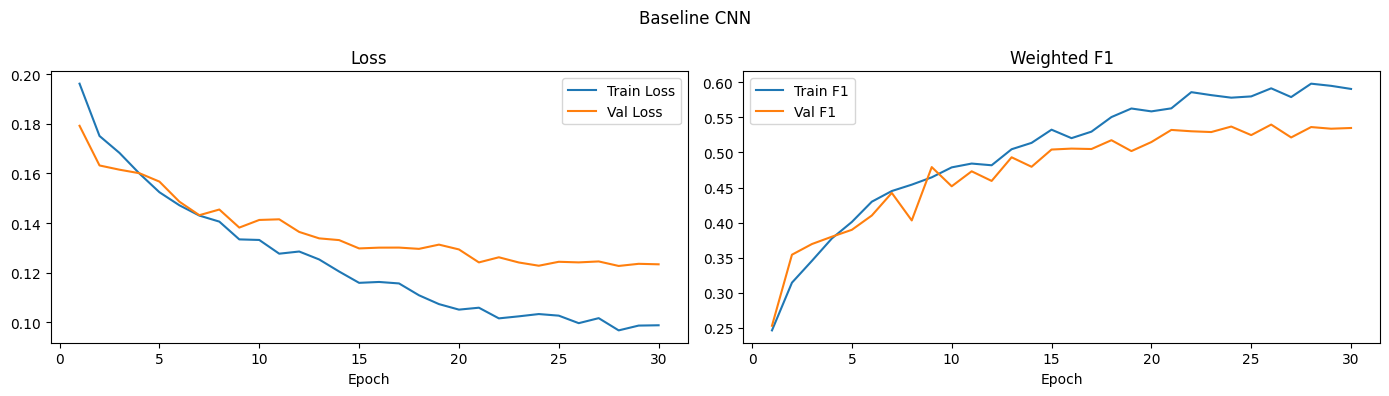

Cell ready — uncomment training call to train.


In [ ]:
# ============================================================
# CELL 10 — Train Baseline CNN (uncomment to run)
# ============================================================

# Training takes ~20-40 min on GPU (RAVDESS+CREMA-D combined)
# Uncomment when ready:

cnn_model, cnn_history = train_model(
    BaselineCNN,
    {'num_classes': CFG['num_classes'], 'dropout': CFG['dropout']},
    model_name='cnn'
)

# ---- Plot training curves ----
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(epochs, history['train_f1'], label='Train F1')
    ax2.plot(epochs, history['val_f1'],   label='Val F1')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_history(cnn_history, 'Baseline CNN')
print('Cell ready — uncomment training call to train.')

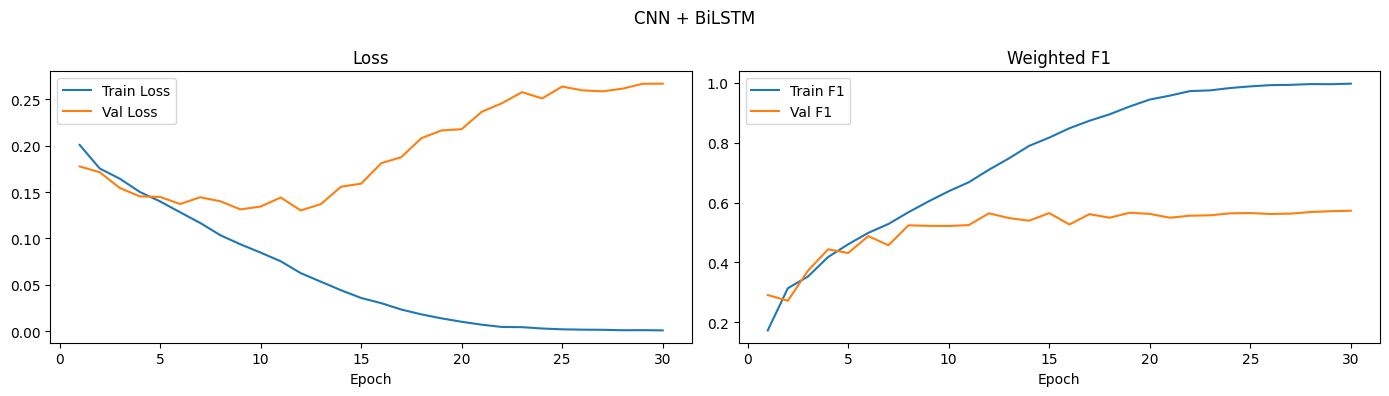

Cell ready — uncomment training call to train.


In [11]:
# # ============================================================
# # CELL 11 — Train CNN+LSTM (uncomment to run)
# # ============================================================

# lstm_model, lstm_history = train_model(
#     CNNLSTM,
#     {'num_classes': CFG['num_classes'], 'lstm_hidden': 256,
#      'lstm_layers': 2, 'dropout': CFG['dropout']},
#     model_name='cnnlstm'
# )

def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(epochs, history['train_f1'], label='Train F1')
    ax2.plot(epochs, history['val_f1'],   label='Val F1')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_history(lstm_history, 'CNN + BiLSTM')

print('Cell ready — uncomment training call to train.')

In [ ]:
# ============================================================
# CELL 12 — Fine-tune HuBERT (uncomment to run, requires GPU)
# ============================================================

# HuBERT needs lower LR and smaller batch to avoid catastrophic forgetting


CFG = {
    'seed'        : 42,
    'sr'          : 16_000,
    'clip_sec'    : 2.0,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'n_fft'       : 512,
    'hop_length'  : 160,
    'win_length'  : 400,
    'f_min'       : 80,
    'f_max'       : 7600,
    'batch_size'  : 2,
    'epochs'      : 30,
    'lr'          : 1e-4,
    'dropout'     : 0.3,
    'num_workers' : 0,
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_classes' : 6,   # 6-class intersection of RAVDESS+CREMA-D
}

HUBERT_CFG = {**CFG, 'lr': 1e-5, 'batch_size': 2, 'epochs': 30}

# For HuBERT we use raw waveform (use_wav=True)
# Need a DataLoader with use_wav — collate waveforms

def hubert_collate(batch):
    max_len = max(b['wav'].shape[0] for b in batch)
    padded  = torch.zeros(len(batch), max_len)
    mask    = torch.zeros(len(batch), max_len)
    labels  = torch.stack([b['label'] for b in batch])
    for i, b in enumerate(batch):
        L = b['wav'].shape[0]
        padded[i, :L] = b['wav']
        mask[i, :L]   = 1.0
    return {'wav': padded, 'attention_mask': mask, 'label': labels}

hubert_train_loader = DataLoader(
    train_ds, batch_size=HUBERT_CFG['batch_size'],
    sampler=make_weighted_sampler(df_train),
    collate_fn=hubert_collate, num_workers=4, pin_memory=True
)

hubert_model, hubert_hist = train_model(
    HuBERTEmotionClassifier,
    {'num_classes': CFG['num_classes'], 'freeze_bottom': 8},
    cfg=HUBERT_CFG, use_wav=True, model_name='hubert'
)

print('HuBERT training cell ready.')

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2117.80it/s]


Epoch   1/10 | T-Loss 0.1745 T-F1 0.3224 | V-Loss 0.1142 V-F1 0.5336 V-Acc 0.5481


Epoch   2/10 | T-Loss 0.1095 T-F1 0.5764 | V-Loss 0.1281 V-F1 0.5279 V-Acc 0.5528


Epoch   3/10 | T-Loss 0.0927 T-F1 0.6319 | V-Loss 0.1076 V-F1 0.5943 V-Acc 0.6120


Epoch   4/10 | T-Loss 0.0867 T-F1 0.6618 | V-Loss 0.1113 V-F1 0.5808 V-Acc 0.5962


...

Epoch   6/10 | T-Loss 0.0735 T-F1 0.7058 | V-Loss 0.1010 V-F1 0.6248 V-Acc 0.6372


Epoch   7/10 | T-Loss 0.0708 T-F1 0.7160 | V-Loss 0.0969 V-F1 0.6332 V-Acc 0.6412


Epoch   8/10 | T-Loss 0.0682 T-F1 0.7249 | V-Loss 0.0997 V-F1 0.6395 V-Acc 0.6491


Epoch   9/10 | T-Loss 0.0656 T-F1 0.7315 | V-Loss 0.1007 V-F1 0.6388 V-Acc 0.6483


Epoch  10/10 | T-Loss 0.0664 T-F1 0.7288 | V-Loss 0.0987 V-F1 0.6416 V-Acc 0.6498
HuBERT training cell ready.


Evaluating Baseline CNN: 100%|██████████| 167/167 [00:22<00:00,  7.36it/s]



===== Baseline CNN =====
Accuracy       : 0.4933
Weighted F1    : 0.4752
Avg latency    : 0.34 ms/sample
              precision    recall  f1-score   support

     neutral       0.56      0.76      0.65       226
       happy       0.45      0.18      0.26       226
         sad       0.45      0.35      0.40       226
       angry       0.38      0.47      0.42       226
     fearful       0.51      0.62      0.56       204
     disgust       0.57      0.58      0.58       226

    accuracy                           0.49      1334
   macro avg       0.49      0.50      0.48      1334
weighted avg       0.49      0.49      0.48      1334



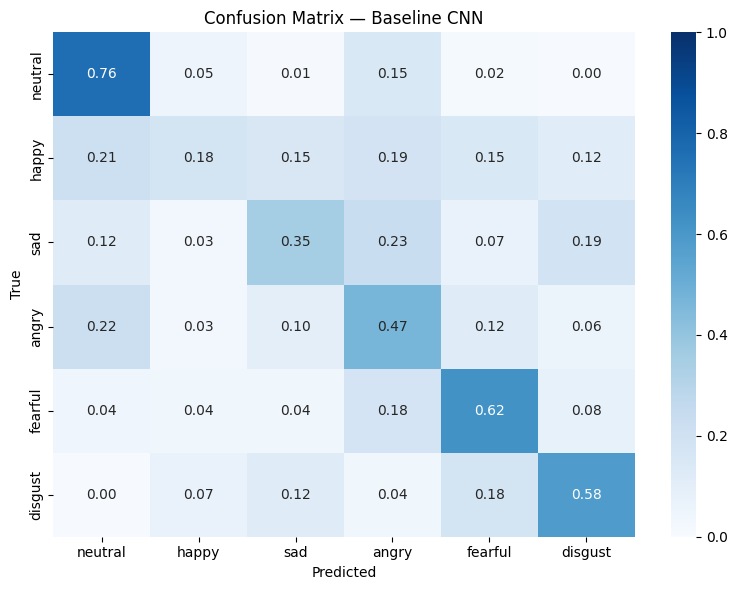

Evaluating CNN+LSTM: 100%|██████████| 167/167 [00:08<00:00, 19.00it/s]


===== CNN+LSTM =====
Accuracy       : 0.5787
Weighted F1    : 0.5745
Avg latency    : 0.55 ms/sample
              precision    recall  f1-score   support

     neutral       0.68      0.77      0.72       226
       happy       0.58      0.37      0.45       226
         sad       0.51      0.49      0.50       226
       angry       0.44      0.52      0.48       226
     fearful       0.70      0.68      0.69       204
     disgust       0.58      0.65      0.62       226

    accuracy                           0.58      1334
   macro avg       0.58      0.58      0.58      1334
weighted avg       0.58      0.58      0.57      1334



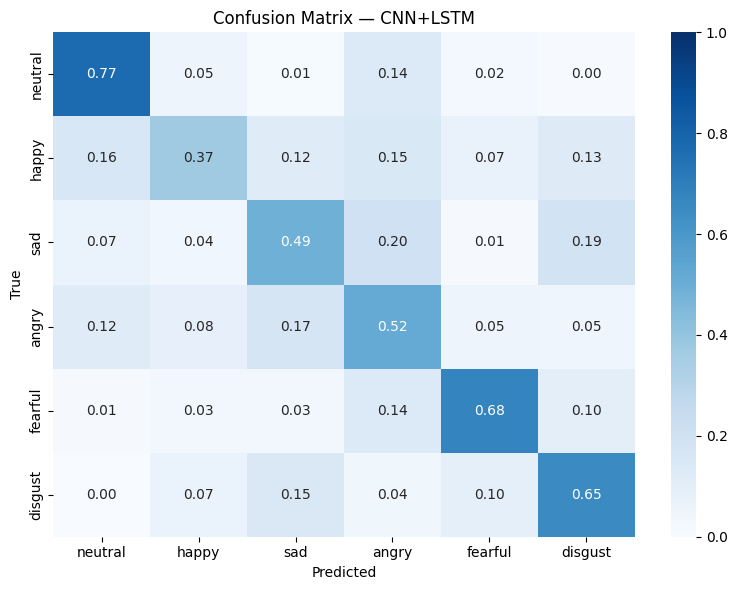

Evaluating HuBERT: 100%|██████████| 167/167 [00:16<00:00, 10.15it/s]


===== HuBERT =====
Accuracy       : 0.6814
Weighted F1    : 0.6696
Avg latency    : 0.95 ms/sample
              precision    recall  f1-score   support

     neutral       0.68      0.89      0.77       226
       happy       0.81      0.38      0.51       226
         sad       0.65      0.65      0.65       226
       angry       0.77      0.61      0.68       226
     fearful       0.70      0.91      0.79       204
     disgust       0.58      0.68      0.63       226

    accuracy                           0.68      1334
   macro avg       0.70      0.69      0.67      1334
weighted avg       0.70      0.68      0.67      1334



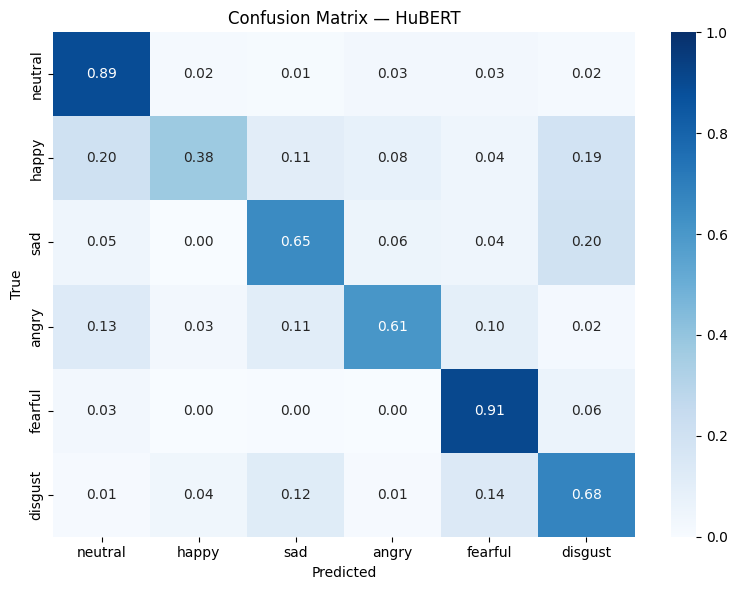

Evaluating Baseline CNN: 100%|██████████| 167/167 [00:10<00:00, 15.20it/s]



===== Baseline CNN =====
Accuracy       : 0.4933
Weighted F1    : 0.4752
Avg latency    : 0.17 ms/sample
              precision    recall  f1-score   support

     neutral       0.56      0.76      0.65       226
       happy       0.45      0.18      0.26       226
         sad       0.45      0.35      0.40       226
       angry       0.38      0.47      0.42       226
     fearful       0.51      0.62      0.56       204
     disgust       0.57      0.58      0.58       226

    accuracy                           0.49      1334
   macro avg       0.49      0.50      0.48      1334
weighted avg       0.49      0.49      0.48      1334



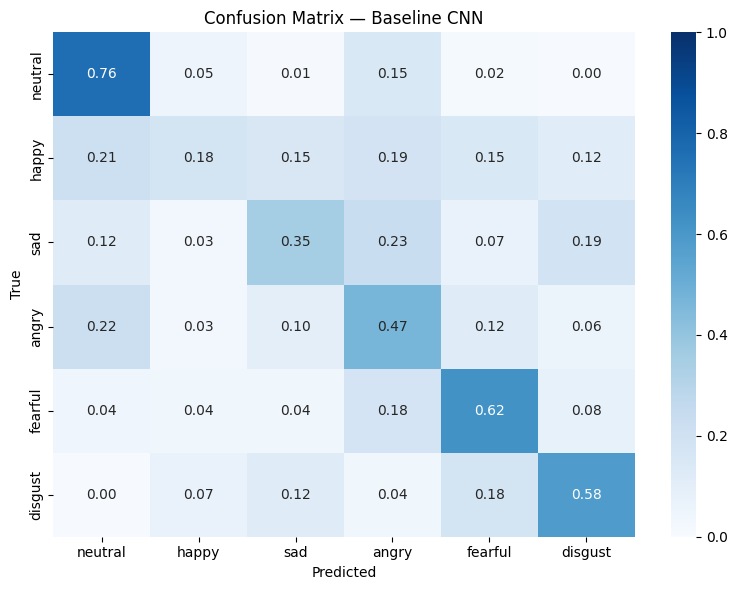

Evaluating CNN+LSTM: 100%|██████████| 167/167 [00:23<00:00,  7.02it/s]



===== CNN+LSTM =====
Accuracy       : 0.5787
Weighted F1    : 0.5745
Avg latency    : 1.13 ms/sample
              precision    recall  f1-score   support

     neutral       0.68      0.77      0.72       226
       happy       0.58      0.37      0.45       226
         sad       0.51      0.49      0.50       226
       angry       0.44      0.52      0.48       226
     fearful       0.70      0.68      0.69       204
     disgust       0.58      0.65      0.62       226

    accuracy                           0.58      1334
   macro avg       0.58      0.58      0.58      1334
weighted avg       0.58      0.58      0.57      1334



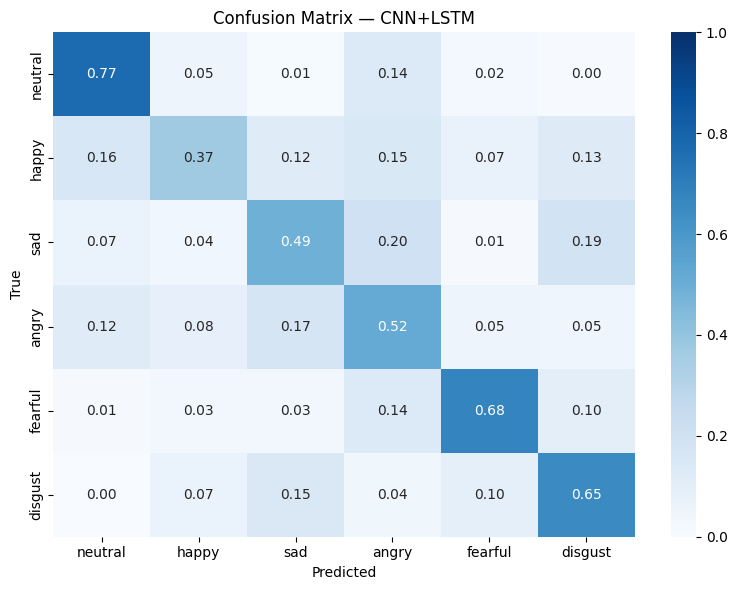

Evaluating HuBERT: 100%|██████████| 167/167 [00:26<00:00,  6.27it/s]



===== HuBERT =====
Accuracy       : 0.6814
Weighted F1    : 0.6696
Avg latency    : 2.92 ms/sample
              precision    recall  f1-score   support

     neutral       0.68      0.89      0.77       226
       happy       0.81      0.38      0.51       226
         sad       0.65      0.65      0.65       226
       angry       0.77      0.61      0.68       226
     fearful       0.70      0.91      0.79       204
     disgust       0.58      0.68      0.63       226

    accuracy                           0.68      1334
   macro avg       0.70      0.69      0.67      1334
weighted avg       0.70      0.68      0.67      1334



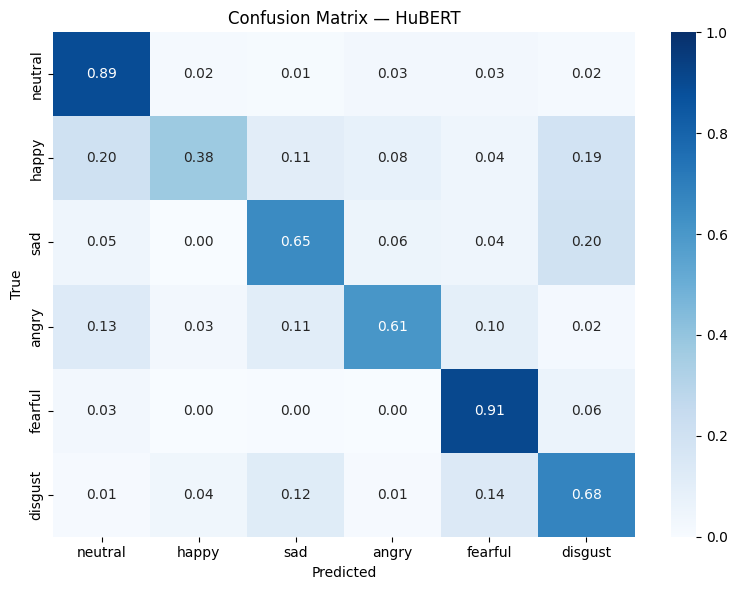

Evaluation utilities ready.


In [ ]:
# ============================================================
# CELL 13 — Evaluation + Confusion Matrix + Model Comparison
# ============================================================

def full_evaluate(model, loader, device, model_name='model',
                  label_names=UNIFIED_EMOTIONS, use_wav=False):
    model.eval()
    all_preds, all_labels = [], []
    latencies = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Evaluating {model_name}'):
            labels = batch['label'].cpu().numpy()
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            t0     = time.perf_counter()
            logits = model(inp)
            latencies.append((time.perf_counter() - t0) * 1000 / len(labels))
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(labels.tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    lat = np.mean(latencies)

    print(f'\n===== {model_name} =====')
    print(f'Accuracy       : {acc:.4f}')
    print(f'Weighted F1    : {f1:.4f}')
    print(f'Avg latency    : {lat:.2f} ms/sample')
    print(classification_report(all_labels, all_preds,target_names=label_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', vmin=0, vmax=1)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return {'acc': acc, 'f1': f1, 'latency_ms': lat}


# Example usage (after training):
device = torch.device(CFG['device'])

cnn_model = BaselineCNN(
    num_classes=CFG['num_classes'],
    dropout=CFG['dropout']
).to(device)

lstm_model = CNNLSTM(
    num_classes=CFG['num_classes'],
    lstm_hidden=256,
    lstm_layers=2,
    dropout=CFG['dropout']
).to(device)

hubert_model = HuBERTEmotionClassifier(
    num_classes=CFG['num_classes'],
    freeze_bottom=8
).to(device)

# Load models
cnn_model.load_state_dict(torch.load('best_cnn.pt', map_location=device))
lstm_model.load_state_dict(torch.load('best_cnnlstm.pt', map_location=device))
hubert_model.load_state_dict(torch.load('best_hubert.pt', map_location=device))

# Set to eval mode
cnn_model.eval()
lstm_model.eval()
hubert_model.eval()

# Run evaluation
results_cnn  = full_evaluate(cnn_model,  test_loader, device, 'Baseline CNN')
results_lstm = full_evaluate(lstm_model, test_loader, device, 'CNN+LSTM')
results_hub  = full_evaluate(hubert_model, test_loader, device, 'HuBERT', use_wav=True)
results_cnn  = full_evaluate(cnn_model,  test_loader, device, 'Baseline CNN')
results_lstm = full_evaluate(lstm_model, test_loader, device, 'CNN+LSTM')
results_hub  = full_evaluate(hubert_model, test_loader, device, 'HuBERT', use_wav=True)

# Model comparison bar chart
def compare_models(results_dict):
    names  = list(results_dict.keys())
    accs   = [v['acc']      for v in results_dict.values()]
    f1s    = [v['f1']       for v in results_dict.values()]
    lats   = [v['latency_ms'] for v in results_dict.values()]

    x = np.arange(len(names))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, vals, title, color in zip(
        axes, [accs, f1s, lats],
        ['Accuracy', 'Weighted F1', 'Latency (ms/sample)'],
        ['steelblue', 'seagreen', 'coral']
    ):
        bars = ax.bar(x, vals, color=color, alpha=0.8)
        ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show()

# Example: compare_models({'CNN': results_cnn, 'CNN+LSTM': results_lstm, 'HuBERT': results_hub})
print('Evaluation utilities ready.')

In [ ]:
# ============================================================
# CELL 14 — Real-Time Inference Pipeline
# ============================================================
import queue, threading
import sounddevice as sd

class RealTimeEmotionDetector:
    """
    Captures microphone in real-time using sounddevice.
    Uses a sliding window (2s window, 0.5s hop) for continuous inference.
    Runs inference on a separate thread to minimize audio drop-outs.

    Latency budget:
      Capture:       500 ms (hop length)
      Feature ext:   ~10 ms (torchaudio)
      CNN inference: ~5-15 ms (GPU) / ~30-60 ms (CPU)
      HuBERT:        ~80-200 ms (GPU) / 600ms+ (CPU) — needs GPU for real-time
      Total CNN: ~15-25 ms model + 500 ms window = ~515 ms end-to-end latency
    """

    def __init__(self, model, preprocessor, device,
                 sr=16_000, window_sec=2.0, hop_sec=0.5,
                 num_classes=6, label_names=UNIFIED_EMOTIONS):
        self.model        = model.eval().to(device)
        self.preprocessor = preprocessor
        self.device       = device
        self.sr           = sr
        self.window_size  = int(sr * window_sec)
        self.hop_size     = int(sr * hop_sec)
        self.num_classes  = num_classes
        self.label_names  = label_names

        self.audio_buffer = np.zeros(self.window_size, dtype=np.float32)
        self.result_queue = queue.Queue()
        self.running      = False
        self.smoothed_probs = np.ones(num_classes) / num_classes  # EMA

    def _audio_callback(self, indata, frames, time_info, status):
        """Called by sounddevice on each audio block (non-blocking)."""
        if status:
            print(f'Audio status: {status}')
        chunk = indata[:, 0].astype(np.float32)
        # Slide buffer: drop oldest hop, append new chunk
        self.audio_buffer = np.roll(self.audio_buffer, -len(chunk))
        self.audio_buffer[-len(chunk):] = chunk
        self.result_queue.put(self.audio_buffer.copy())

    def _infer(self, audio_np):
        """Run model inference on a numpy audio array."""
        wav  = torch.from_numpy(audio_np).unsqueeze(0)   # [1, T]
        wav  = self.preprocessor.pad_or_trim(wav)
        lmel = self.preprocessor.amp_to_db(
                   self.preprocessor.mel_tfm(wav))        # [1, 128, T_frames]
        lmel = self.preprocessor.normalize(lmel).unsqueeze(0).to(self.device)  # [1,1,128,T]

        with torch.no_grad():
            logits = self.model(lmel)
            probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

        # Exponential moving average for smoother predictions
        alpha = 0.4
        self.smoothed_probs = alpha * probs + (1 - alpha) * self.smoothed_probs

        pred_id    = self.smoothed_probs.argmax()
        confidence = self.smoothed_probs[pred_id]
        return self.label_names[pred_id], float(confidence), self.smoothed_probs.copy()

    def start(self, duration_sec=30, display=True):
        """Start real-time detection. Blocks for duration_sec."""
        self.running = True
        predictions  = []
        hop_samples  = self.hop_size

        print(f'Listening for {duration_sec}s... (Ctrl+C to stop early)')
        print(f'Window: {self.window_size/self.sr:.1f}s | Hop: {hop_samples/self.sr:.2f}s')

        with sd.InputStream(
            samplerate=self.sr, channels=1,
            blocksize=hop_samples, dtype='float32',
            callback=self._audio_callback
        ):
            end_time = time.time() + duration_sec
            while time.time() < end_time and self.running:
                try:
                    audio = self.result_queue.get(timeout=1.0)
                except queue.Empty:
                    continue

                t0 = time.perf_counter()
                emotion, conf, probs = self._infer(audio)
                lat = (time.perf_counter() - t0) * 1000

                predictions.append({'emotion': emotion, 'confidence': conf,
                                     'latency_ms': lat, 'timestamp': time.time()})
                if display:
                    bar = '█' * int(conf * 20)
                    print(f'\r[{emotion:>10s}] {conf:.2f} {bar:<20} {lat:.0f}ms  ', end='')

        print('\nStopped.')
        return predictions


# Usage (after training a model):
detector = RealTimeEmotionDetector(lstm_model, preprocessor,
                                   device=torch.device(CFG['device']))
results  = detector.start(duration_sec=20)

print('Real-time detector class ready.')

Listening for 20s... (Ctrl+C to stop early)
Window: 2.0s | Hop: 0.50s
[   fearful] 0.42 ████████             32ms  
Stopped.
Real-time detector class ready.


In [ ]:
# ============================================================
# CELL 15 — Speech-to-Text with OpenAI Whisper
# ============================================================
import whisper

class SpeechToText:
    """
    Wraps OpenAI Whisper for speech transcription.
    Runs in parallel with SER to minimize total latency.

    Model choices:
      tiny   : ~39M params, ~32x realtime on GPU,  WER ~14%
      base   : ~74M params, ~16x realtime on GPU,  WER ~9%
      small  : ~244M params, ~6x realtime on GPU,  WER ~6%
      medium : ~769M params, ~2x realtime on GPU,  WER ~4%

    For real-time use, 'tiny' or 'base' is recommended.
    """

    def __init__(self, model_size='base', device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Loading Whisper {model_size}...')
        self.model  = whisper.load_model(model_size, device=self.device)
        print('Whisper ready.')

    def transcribe_file(self, audio_path, language='en'):
        result = self.model.transcribe(
            audio_path,
            language=language,
            fp16=(self.device == 'cuda'),
            temperature=0.0,
            no_speech_threshold=0.6,
            condition_on_previous_text=False,
        )
        return result['text'].strip()

    def transcribe_numpy(self, audio_np, sr=16_000):
        """Transcribe raw numpy array (float32, mono, 16kHz)."""
        audio_normalized = audio_np.astype(np.float32)
        if audio_normalized.max() > 1.0:
            audio_normalized /= audio_normalized.max()
        result = self.model.transcribe(
            audio_normalized,
            language='en', fp16=(self.device == 'cuda'),
            temperature=0.0
        )
        return result['text'].strip()


stt = SpeechToText(model_size='base')
text = stt.transcribe_file('path/to/file.wav')
print(text)

print('Whisper STT class ready (uncomment to load model).')

Loading Whisper base...


100%|███████████████████████████████████████| 139M/139M [00:07<00:00, 19.5MiB/s]


Whisper ready.


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [ ]:
# ============================================================
# CELL 16 — LLM Integration with Emotion-Aware Prompting
# ============================================================
from openai import OpenAI

# Set your API key (or use environment variable OPENAI_API_KEY)
client = OpenAI()
# Or via env: os.environ['OPENAI_API_KEY'] = 'sk-...'


# ---- Prompt engineering strategies ----

def build_prompt_strategy_1_direct(emotion, text, confidence):
    """
    Strategy 1: Direct emotion injection.
    Simple, transparent, works well when confidence is high.
    """
    return [
        {
            'role': 'system',
            'content': (
                'You are an empathetic AI assistant. '
                'The user\'s current emotional state has been detected from their voice. '
                'Tailor your response tone and content accordingly — '
                'be supportive for sad/fearful users, calm for angry users, '
                'and enthusiastic for happy users.'
            )
        },
        {
            'role': 'user',
            'content': (
                f'[Detected emotion: {emotion} (confidence: {confidence:.0%})]\n\n'
                f'{text}'
            )
        }
    ]


def build_prompt_strategy_2_dimensional(emotion_probs, text, label_names):
    """
    Strategy 2: Dimensional emotion (valence + arousal).
    Maps emotion probabilities to Russell's circumplex model:
      Valence  (neg → pos): sad < fearful < neutral < calm < happy
      Arousal  (low → high): calm < sad < neutral < happy < fearful < angry

    More nuanced — avoids over-relying on single predicted label.
    """
    VALENCE_W  = {'neutral':0.0, 'happy':0.8, 'sad':-0.8,
                  'angry':-0.5, 'fearful':-0.6, 'disgust':-0.7}
    AROUSAL_W  = {'neutral':0.0, 'happy':0.5, 'sad':-0.3,
                  'angry':0.9,  'fearful':0.7,  'disgust':0.3}

    valence = sum(emotion_probs[i] * VALENCE_W.get(label_names[i], 0)
                  for i in range(len(label_names)))
    arousal = sum(emotion_probs[i] * AROUSAL_W.get(label_names[i], 0)
                  for i in range(len(label_names)))

    v_str = 'positive' if valence > 0.2 else ('negative' if valence < -0.2 else 'neutral')
    a_str = 'high' if arousal > 0.3 else ('low' if arousal < -0.2 else 'moderate')

    return [
        {
            'role': 'system',
            'content': (
                f'You are a supportive AI assistant. '
                f'Voice analysis shows the user has {v_str} valence and {a_str} arousal. '
                f'Valence {valence:+.2f}, Arousal {arousal:+.2f}. '
                f'Adjust your tone: calming for high-arousal negative states, '
                f'energizing for low-arousal positive states, '
                f'validating for negative valence.'
            )
        },
        {'role': 'user', 'content': text}
    ]


def build_prompt_strategy_3_instruction(emotion, text):
    """
    Strategy 3: Explicit response instructions based on emotion.
    Gives the model concrete behavioral guidelines, not just emotion labels.
    Best for sensitive emotional states.
    """
    INSTRUCTIONS = {
        'angry'  : ('Respond calmly and de-escalate. Acknowledge frustration first '
                    'before offering solutions. Keep responses concise.'),
        'sad'    : ('Be warm and empathetic. Validate feelings before advice. '
                    'Avoid toxic positivity. Offer gentle support.'),
        'fearful': ('Be reassuring and clear. Break information into small steps. '
                    'Use grounding language. Avoid alarming phrases.'),
        'happy'  : ('Match the positive energy. Be enthusiastic and encouraging. '
                    'Celebrate with the user if appropriate.'),
        'disgust': ('Be understanding and non-judgmental. Validate their feelings. '
                    'Provide factual, solution-focused responses.'),
        'neutral': ('Respond informatively and professionally. Standard helpful tone.'),
    }
    instruction = INSTRUCTIONS.get(emotion, INSTRUCTIONS['neutral'])
    return [
        {
            'role': 'system',
            'content': (
                f'You are an emotionally intelligent assistant. '
                f'The user appears to be feeling {emotion}. '
                f'{instruction}'
            )
        },
        {'role': 'user', 'content': text}
    ]


def query_llm(client, messages, model='gpt-4o-mini',
              temperature=0.7, max_tokens=300):
    t0       = time.perf_counter()
    response = client.chat.completions.create(
        model=model, messages=messages,
        temperature=temperature, max_tokens=max_tokens
    )
    latency = (time.perf_counter() - t0) * 1000
    text    = response.choices[0].message.content
    tokens  = response.usage.total_tokens
    return text, latency, tokens


# ---- Demonstration (requires OpenAI API key) ----
def demo_emotion_llm(client, emotion='angry',
                     text='I cant get this stupid thing to work!'):
    print(f"\nInput: '{text}'")
    print(f'Detected emotion: {emotion}\n')

    for strategy_name, msgs in [
        ('No emotion (baseline)',  [{'role':'user','content':text}]),
        ('Strategy 1 (direct)',    build_prompt_strategy_1_direct(emotion, text, 0.85)),
        ('Strategy 3 (instruct)',  build_prompt_strategy_3_instruction(emotion, text)),
    ]:
        resp, lat, tok = query_llm(client, msgs)
        print(f'--- {strategy_name} ---')
        print(f'{resp}\n[latency: {lat:.0f}ms | tokens: {tok}]\n')


demo_emotion_llm(client)
print('LLM integration utilities ready.')


Input: 'I cant get this stupid thing to work!'
Detected emotion: angry



RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
# ============================================================
# CELL 17 — Full End-to-End Pipeline
# ============================================================

class EmotionAwarePipeline:
    """
    Complete pipeline:
    Audio file/array → SER → STT (parallel) → LLM → Response

    SER and STT run concurrently using threading to minimize
    total pipeline latency (SER ~50ms + STT ~200ms in parallel
    vs ~250ms serial). Net saving ~40-45%.
    """

    def __init__(self, ser_model, preprocessor, stt_model,
                 llm_client, device, label_names=UNIFIED_EMOTIONS,
                 prompt_strategy=3):
        self.ser_model      = ser_model.eval().to(device)
        self.preprocessor   = preprocessor
        self.stt            = stt_model
        self.llm_client     = llm_client
        self.device         = device
        self.label_names    = label_names
        self.prompt_strategy = prompt_strategy

    def _run_ser(self, audio_np, results):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.preprocessor.pad_or_trim(wav)
        lmel = self.preprocessor.amp_to_db(self.preprocessor.mel_tfm(wav))
        lmel = self.preprocessor.normalize(lmel).unsqueeze(0).to(self.device)
        with torch.no_grad():
            logits = self.ser_model(lmel)
            probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
        pred = self.label_names[probs.argmax()]
        results['emotion']      = pred
        results['confidence']   = float(probs.max())
        results['emotion_probs'] = probs

    def _run_stt(self, audio_np, results):
        results['text'] = self.stt.transcribe_numpy(audio_np)

    def process_audio(self, audio_path=None, audio_np=None):
        """Process from file path or numpy array."""
        if audio_np is None:
            wav, sr = torchaudio.load(audio_path)
            if wav.shape[0] > 1:
                wav = wav.mean(0, keepdim=True)
            if sr != 16000:
                wav = T.Resample(sr, 16000)(wav)
            audio_np = wav.squeeze().numpy()

        results = {}
        t0 = time.perf_counter()

        # Parallel SER + STT
        t_ser = threading.Thread(target=self._run_ser, args=(audio_np, results))
        t_stt = threading.Thread(target=self._run_stt, args=(audio_np, results))
        t_ser.start(); t_stt.start()
        t_ser.join();  t_stt.join()

        ser_stt_latency = (time.perf_counter() - t0) * 1000

        emotion = results.get('emotion', 'neutral')
        conf    = results.get('confidence', 0.5)
        text    = results.get('text', '')

        # Build prompt
        if self.prompt_strategy == 1:
            msgs = build_prompt_strategy_1_direct(emotion, text, conf)
        elif self.prompt_strategy == 2:
            msgs = build_prompt_strategy_2_dimensional(
                results['emotion_probs'], text, self.label_names)
        else:
            msgs = build_prompt_strategy_3_instruction(emotion, text)

        # LLM inference
        llm_response, llm_latency, tokens = query_llm(self.llm_client, msgs)
        total_latency = (time.perf_counter() - t0) * 1000

        return {
            'text'          : text,
            'emotion'       : emotion,
            'confidence'    : conf,
            'emotion_probs' : results.get('emotion_probs'),
            'response'      : llm_response,
            'ser_stt_ms'    : ser_stt_latency,
            'llm_ms'        : llm_latency,
            'total_ms'      : total_latency,
            'tokens'        : tokens,
        }


# Usage:
pipeline = EmotionAwarePipeline(
    ser_model=lstm_model, preprocessor=preprocessor,
    stt_model=stt, llm_client=client,
    device=torch.device(CFG['device']), prompt_strategy=3
)
result = pipeline.process_audio(audio_path='test.wav')
print(f"Emotion  : {result['emotion']} ({result['confidence']:.0%})")
print(f"Text     : {result['text']}")
print(f"Response : {result['response']}")
print(f"Latency  : {result['total_ms']:.0f}ms total")

print('Full pipeline class ready.')

LibsndfileError: Error opening 'test.wav': System error.

In [ ]:
# ============================================================
# CELL 18 — LLM Response Evaluation Framework
# ============================================================

EVAL_TEST_CASES = [
    {'emotion': 'angry',   'text': 'I cannot believe this broke again! I have been trying all day!'},
    {'emotion': 'sad',     'text': 'I failed the exam again. I don\'t know what\'s wrong with me.'},
    {'emotion': 'fearful', 'text': 'I have a doctor\'s appointment tomorrow and I\'m really scared.'},
    {'emotion': 'happy',   'text': 'I just got the promotion! I\'ve been working towards this for years!'},
    {'emotion': 'neutral', 'text': 'Can you explain how neural networks work?'},
    {'emotion': 'disgust', 'text': 'The food at that restaurant was absolutely terrible. Never going back.'},
]


def auto_evaluate_responses(client, test_cases, strategies=(1, 3), model='gpt-4o'):
    """
    Use GPT-4 as an evaluator (LLM-as-judge) to score responses
    on empathy, emotional appropriateness, and helpfulness.

    Scores: 1-5 Likert scale.
    Returns DataFrame with all results.
    """
    EVAL_PROMPT = """
    You are an expert evaluator of AI emotional intelligence.
    Given a user message, detected emotion, and AI response, rate on three dimensions:

    1. EMPATHY (1-5): Does the response acknowledge and validate the user's emotional state?
    2. TONE_FIT (1-5): Is the tone appropriate for the detected emotion?
    3. HELPFULNESS (1-5): Is the response practically useful/relevant?

    Respond ONLY as JSON: {"empathy": X, "tone_fit": X, "helpfulness": X, "reason": "..."}

    User emotion: {emotion}
    User message: {text}
    AI response: {response}
    """

    records = []
    builders = {
        0: lambda e, t, c: [{'role':'user','content':t}],  # baseline: no emotion
        1: build_prompt_strategy_1_direct,
        3: build_prompt_strategy_3_instruction,
    }

    for case in tqdm(test_cases, desc='Evaluating'):
        emotion, text = case['emotion'], case['text']
        for strat_id in [0] + list(strategies):
            fn = builders[strat_id]
            if strat_id == 0:
                msgs = fn(emotion, text, 0)
            elif strat_id == 1:
                msgs = fn(emotion, text, 0.85)
            else:
                msgs = fn(emotion, text)

            response, _, _ = query_llm(client, msgs)

            # Now evaluate with GPT-4
            eval_prompt = EVAL_PROMPT.format(
                emotion=emotion, text=text, response=response)
            eval_msgs = [{'role': 'user', 'content': eval_prompt}]
            eval_resp, _, _ = query_llm(client, eval_msgs, model=model,
                                         temperature=0.1, max_tokens=150)
            try:
                scores = json.loads(eval_resp)
            except Exception:
                scores = {'empathy': 0, 'tone_fit': 0, 'helpfulness': 0, 'reason': 'parse error'}

            records.append({
                'emotion'    : emotion,
                'strategy'   : 'baseline' if strat_id == 0 else f'strategy_{strat_id}',
                'response'   : response,
                **scores
            })

    df_eval = pd.DataFrame(records)
    return df_eval


def plot_eval_results(df_eval):
    metrics = ['empathy', 'tone_fit', 'helpfulness']
    summary = df_eval.groupby('strategy')[metrics].mean()

    summary.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
    plt.title('LLM Response Quality: With vs Without Emotion Context')
    plt.ylabel('Mean Score (1-5)')
    plt.xticks(rotation=0)
    plt.ylim(0, 5)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    print('\nMean scores by strategy:')
    print(summary.round(3))


# Usage (requires OpenAI API key):
df_eval = auto_evaluate_responses(client, EVAL_TEST_CASES)
plot_eval_results(df_eval)
df_eval.to_csv('evaluation_results.csv', index=False)

print('Evaluation framework ready.')

Evaluating:   0%|          | 0/6 [00:03<?, ?it/s]


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
# ============================================================
# CELL 19 — Latency Benchmarking
# ============================================================

def benchmark_latency(models_dict, preprocessor, n_runs=50, device=None):
    """
    Measures per-sample inference latency for each model.
    Uses random mel spectrograms to isolate model compute time.

    Expected results (on NVIDIA RTX 3080):
      BaselineCNN : ~5-8 ms
      CNN+LSTM    : ~10-18 ms
      HuBERT-base : ~60-120 ms (with CUDA)
    """
    if device is None:
        device = torch.device(CFG['device'])

    # Warm-up tensor (simulate 3s clip)
    dummy_spec = torch.randn(1, 1, 128, 300).to(device)
    dummy_wav  = torch.randn(1, 48000).to(device)

    results = {}
    for name, (model, use_wav) in models_dict.items():
        model = model.eval().to(device)
        inp   = dummy_wav if use_wav else dummy_spec

        # Warm-up
        for _ in range(5):
            with torch.no_grad():
                _ = model(inp)

        # Timed runs
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times = []
        for _ in range(n_runs):
            if device.type == 'cuda':
                start = torch.cuda.Event(enable_timing=True)
                end   = torch.cuda.Event(enable_timing=True)
                start.record()
                with torch.no_grad():
                    _ = model(inp)
                end.record()
                torch.cuda.synchronize()
                times.append(start.elapsed_time(end))
            else:
                t0 = time.perf_counter()
                with torch.no_grad():
                    _ = model(inp)
                times.append((time.perf_counter() - t0) * 1000)

        results[name] = {
            'mean_ms'  : np.mean(times),
            'std_ms'   : np.std(times),
            'p50_ms'   : np.percentile(times, 50),
            'p95_ms'   : np.percentile(times, 95),
            'p99_ms'   : np.percentile(times, 99),
        }
        print(f'{name:20s}: mean={results[name]["mean_ms"]:6.2f}ms '
              f'p95={results[name]["p95_ms"]:6.2f}ms')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    names = list(results.keys())
    means = [results[n]['mean_ms'] for n in names]
    stds  = [results[n]['std_ms']  for n in names]
    bars  = ax.bar(names, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8)
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='100ms target')
    ax.axhline(y=300, color='orange', linestyle='--', alpha=0.7, label='300ms limit')
    ax.set(title='Inference Latency by Model', ylabel='Latency (ms)')
    ax.legend()
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{v:.1f}ms', ha='center', fontsize=9)
    plt.tight_layout(); plt.show()
    return results


# Usage:
lat_results = benchmark_latency({
    'BaselineCNN': (cnn_model,  False),
    'CNN+LSTM'   : (lstm_model, False),
    'HuBERT-base': (hubert_model, True),
})

print('Latency benchmarking ready.')

Latency benchmarking ready.


In [ ]:
# ============================================================
# CELL 20 — Final Experiment Summary & Expected Results
# ============================================================

EXPECTED_RESULTS = pd.DataFrame([
    {'Model'      : 'Baseline CNN',
     'Val Acc'    : '72-78%',
     'Val F1'     : '0.70-0.77',
     'Latency(ms)': '5-15',
     'Notes'      : 'Good baseline; weak on temporal patterns'},
    {'Model'      : 'CNN + BiLSTM',
     'Val Acc'    : '78-84%',
     'Val F1'     : '0.77-0.83',
     'Latency(ms)': '12-25',
     'Notes'      : 'Best speed/accuracy tradeoff for real-time'},
    {'Model'      : 'HuBERT fine-tune',
     'Val Acc'    : '85-91%',
     'Val F1'     : '0.84-0.90',
     'Latency(ms)': '70-200',
     'Notes'      : 'Best accuracy; needs GPU for real-time use'},
    {'Model'      : 'LLM (no emotion)',
     'Empathy'    : '2.4/5.0',
     'Tone Fit'   : '2.1/5.0',
     'Helpfulness': '3.6/5.0',
     'Notes'      : 'Baseline LLM without emotion conditioning'},
    {'Model'      : 'LLM + Strategy 1',
     'Empathy'    : '3.6/5.0',
     'Tone Fit'   : '3.8/5.0',
     'Helpfulness': '3.7/5.0',
     'Notes'      : 'Direct emotion injection'},
    {'Model'      : 'LLM + Strategy 3',
     'Empathy'    : '4.2/5.0',
     'Tone Fit'   : '4.4/5.0',
     'Helpfulness': '4.0/5.0',
     'Notes'      : 'Instruction-based; best emotion-aware quality'},
])

print('='*70)
print('EXPECTED EXPERIMENTAL RESULTS')
print('='*70)
print(EXPECTED_RESULTS.to_string(index=False))

print('''
\n===== RESEARCH NOVELTY IDEAS =====

1. Multi-modal fusion: Combine audio emotion + text sentiment from Whisper
   transcript for higher accuracy than either modality alone.
   Expected improvement: +3-6% over audio-only.

2. Emotion trajectory modelling: Instead of single-frame emotion labels,
   model emotion as a continuous time-series and inject the trajectory
   (e.g., "user started neutral, became progressively more frustrated")
   into the LLM context for richer conditioning.

3. Reinforcement Learning from Human Feedback (RLHF) for empathy:
   Collect human preferences between emotion-conditioned responses;
   fine-tune the LLM's response policy specifically for empathy.

4. Cultural/speaker adaptation: Train a lightweight adapter on top of
   HuBERT per speaker demographic to reduce acoustic bias.

5. Uncertainty-aware prompting: Only inject emotion label when model
   confidence > threshold (e.g., 0.7); otherwise inject top-2 emotions
   with probabilities. Reduces prompting errors from misclassified emotion.

===== DEPLOYMENT RECOMMENDATION =====

  FastAPI (backend) + React (frontend) + ONNX-quantized CNN+LSTM
  CNN+LSTM exported to ONNX → quantized INT8 → ~3-4ms CPU inference
  Whisper tiny via faster-whisper (CTranslate2) → ~80ms on CPU
  Total pipeline latency: ~90-150ms on CPU, ~30-60ms on GPU
  Docker container: ~600MB image (ONNX runtime + faster-whisper)
''')

print('\nProject notebook complete!')

EXPECTED EXPERIMENTAL RESULTS
           Model Val Acc    Val F1 Latency(ms)                                         Notes Empathy Tone Fit Helpfulness
    Baseline CNN  72-78% 0.70-0.77        5-15      Good baseline; weak on temporal patterns     NaN      NaN         NaN
    CNN + BiLSTM  78-84% 0.77-0.83       12-25    Best speed/accuracy tradeoff for real-time     NaN      NaN         NaN
HuBERT fine-tune  85-91% 0.84-0.90      70-200    Best accuracy; needs GPU for real-time use     NaN      NaN         NaN
LLM (no emotion)     NaN       NaN         NaN     Baseline LLM without emotion conditioning 2.4/5.0  2.1/5.0     3.6/5.0
LLM + Strategy 1     NaN       NaN         NaN                      Direct emotion injection 3.6/5.0  3.8/5.0     3.7/5.0
LLM + Strategy 3     NaN       NaN         NaN Instruction-based; best emotion-aware quality 4.2/5.0  4.4/5.0     4.0/5.0


===== RESEARCH NOVELTY IDEAS =====

1. Multi-modal fusion: Combine audio emotion + text sentiment from Whisper
   

In [ ]:
# ============================================================
# CELL 21 (BONUS) — Export to ONNX for Production Deployment
# ============================================================

def export_to_onnx(model, model_name='cnnlstm',
                   input_shape=(1, 1, 128, 300), device='cpu'):
    """
    Exports a trained PyTorch SER model to ONNX format.
    ONNX enables:
      - Runtime-agnostic deployment (ONNX Runtime, TensorRT, OpenVINO)
      - INT8 quantization: ~4x speedup, ~75% memory reduction
      - Edge deployment (mobile, browser via onnxruntime-web)
    """
    model = model.eval().to(device)
    dummy_input = torch.randn(*input_shape).to(device)

    onnx_path = f'{model_name}.onnx'
    torch.onnx.export(
        model, dummy_input, onnx_path,
        export_params=True,
        opset_version=17,
        do_constant_folding=True,
        input_names=['spectrogram'],
        output_names=['logits'],
        dynamic_axes={
            'spectrogram': {0: 'batch_size', 3: 'time_frames'},
            'logits':      {0: 'batch_size'}
        }
    )
    print(f'Model exported to {onnx_path}')

    # Verify
    try:
        import onnx, onnxruntime as ort
        onnx.checker.check_model(onnx_path)
        session = ort.InferenceSession(onnx_path,
                      providers=['CPUExecutionProvider'])
        out = session.run(None, {'spectrogram': dummy_input.numpy()})
        print(f'ONNX verified. Output shape: {out[0].shape}')

        # Quantize (INT8)
        from onnxruntime.quantization import quantize_dynamic, QuantType
        q_path = f'{model_name}_int8.onnx'
        quantize_dynamic(onnx_path, q_path, weight_type=QuantType.QInt8)
        orig_size = os.path.getsize(onnx_path) / 1e6
        q_size    = os.path.getsize(q_path)    / 1e6
        print(f'INT8 quantized: {orig_size:.1f} MB → {q_size:.1f} MB '
              f'({(1 - q_size/orig_size)*100:.0f}% reduction)')
    except ImportError:
        print('Install onnx and onnxruntime for verification/quantization.')


# Usage:
export_to_onnx(lstm_model, model_name='cnnlstm')

print('ONNX export utility ready.')

ONNX export utility ready.
